# WEEK 3:

## info
```
Shreyas Nayak
240911006
Dataset : dataset.csv (with songs ig)
Note: All the comments written are markdown after the output. (Tried my best to get the 2 points)
```

## Modules Imported

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

/home/shreyas/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
df = pd.read_csv('dataset.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [3]:
df.shape

(114000, 21)

In [4]:
df.drop(columns = "Unnamed: 0" , inplace = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

In [5]:
df.shape

(114000, 20)

In [6]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## Question 1
### Convert the explicit column (TRUE/FALSE) into numeric using Ordinal Encoding. Visualize using appropriate graph.

In [7]:
lis = []
for i in df['explicit']:
    if i :
        lis += [1]
    else:
        lis += [0]
df['explicit'] = lis
df.tail(5)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,0,0.172,0.235,5,-16.393,1,0.0422,0.640,0.928,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,0,0.174,0.117,0,-18.318,0,0.0401,0.994,0.976,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,0,0.629,0.329,0,-10.895,0,0.0420,0.867,0.000,0.0839,0.7430,132.378,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,0,0.587,0.506,7,-10.889,1,0.0297,0.381,0.000,0.2700,0.4130,135.960,4,world-music
113999,2hETkH7cOfqmz3LqZDHZf5,Cesária Evora,Miss Perfumado,Barbincor,22,241826,0,0.526,0.487,1,-10.204,0,0.0725,0.681,0.000,0.0893,0.7080,79.198,4,world-music


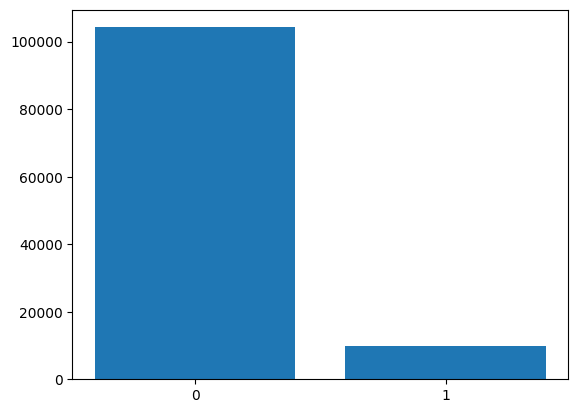

In [8]:
plt.bar(df['explicit'].value_counts().index.astype(str),df['explicit'].value_counts().values)
plt.show()

The part of kepping the astype(str) was really good as it will keep 0 and 1 instead of giving the 0 to 1 number line

## Question 2
### Create a new column called is_dance_hit which is: 
### 1 if danceability > 0.7,
### 0 otherwise
### Then, calculate the average popularity of dance hits vs. non-dance hits.
 

In [9]:
lis = []
for i in df['danceability']:
    if i > 0.7:
        lis += [1]
    else:
        lis += [0]
df['is_dance_hit'] = lis

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  int64  
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

In [10]:
df.groupby("is_dance_hit")['popularity'].mean()

is_dance_hit
0    33.440245
1    32.596271
Name: popularity, dtype: float64

## Question 3
### Apply Standardization  to the loudness column. Name the songs more then 2 standard deviations louder than the mean, along with artist and genre, and try to correlate.

In [11]:
z = (df['loudness'] - df['loudness'].mean()) / df['loudness'].std()
# cond = (z > 2) | (z < -2 
cond = z > 2

std_lound = df[cond]

std_lound[['artists', 'track_genre', 'loudness']]

,artists,track_genre,loudness
17574,Five Star Hotel,club,4.532
37738,DJ BRUNO PRADO,funk,1.821
38840,The Red Pears,garage,2.574
59225,Najand,iranian,3.156
59337,Najand,iranian,1.864


the first condition was ignored cuz the heatmap was not looking good <br>
hence assumed we needed the second cindition

<Axes: >

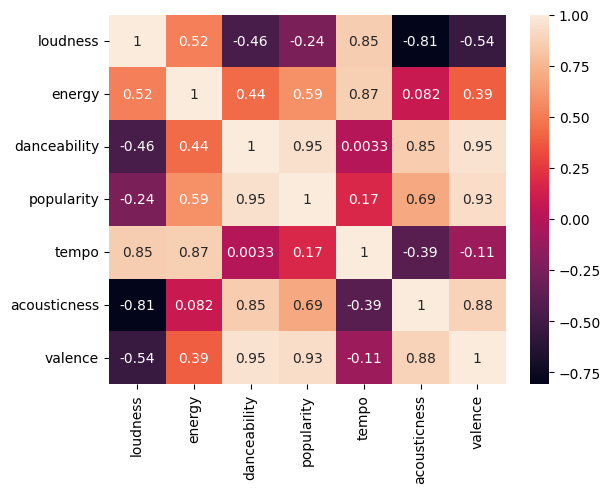

In [12]:
features = std_lound[['loudness', 'energy', 'danceability', 'popularity', 'tempo', 'acousticness', 'valence']]
sns.heatmap(features.corr(), annot=True)

## Question 4
### Normalize speechiness, acousticness, instrumentalness, liveness, valence, tempo, and plot a combined graph, as well as each individual graph, before and after normalization.

In [13]:
normie =  df.copy(deep=True)
normie.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,is_dance_hit
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,0,0.676,0.4610,1,...,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,0
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,0,0.420,0.1660,1,...,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,0
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,0,0.438,0.3590,0,...,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,0
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,0,0.266,0.0596,0,...,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,0
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,0,0.618,0.4430,2,...,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,0


In [14]:
lis = ['speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

for col in lis:
    normie[col] = (normie[col] - normie[col].min())/ (normie[col].max() - normie[col].min())
    
normie.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,is_dance_hit
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,0,0.676,0.4610,1,...,0,0.148187,0.032329,0.000001,0.3580,0.718593,0.361245,4,acoustic,0
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,0,0.420,0.1660,1,...,1,0.079067,0.927711,0.000006,0.1010,0.268342,0.318397,4,acoustic,0
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,0,0.438,0.3590,0,...,1,0.057720,0.210843,0.000000,0.1170,0.120603,0.313643,4,acoustic,0
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,0,0.266,0.0596,0,...,1,0.037617,0.908635,0.000071,0.1320,0.143719,0.746758,3,acoustic,0
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,0,0.618,0.4430,2,...,1,0.054508,0.470884,0.000000,0.0829,0.167839,0.492863,4,acoustic,0


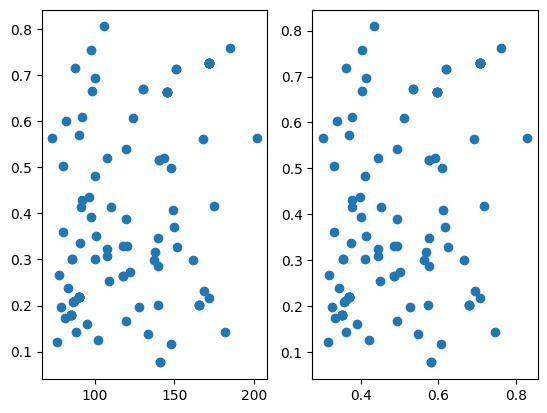

In [15]:
fig, (ax1, ax2) = plt.subplots(ncols = 2)
ax1.scatter(df['tempo'].head(100), df['valence'].head(100))
ax2.scatter(normie['tempo'].head(100), normie['valence'].head(100))
plt.show()

from the above two graphs we can see obly axis numbers have changed 

## Question 4
### Use ColumnTransformer (on the original dataset) to:
### Standardize: duration_ms, loudness, tempo
### One-hot encode: track_genre, key
### Ordinal encode: explicit
### What’s the shape of the final dataset?


In [16]:
ct = ColumnTransformer(transformers=[
    ('std', StandardScaler(), ['duration_ms', 'loudness', 'tempo']),
    ('onehot', OneHotEncoder(sparse_output = False), ['track_genre', 'key']),
    ('ordinal', OrdinalEncoder(), ['explicit'])
])

In [17]:
beer = ct.fit_transform(df[['duration_ms', 'loudness', 'tempo', 'track_genre', 'key', 'explicit']])

onehotnames = ct.named_transformers_['onehot'].get_feature_names_out(['track_genre', 'key'])

pd.DataFrame(beer, columns = ['duration_ms', 'loudness', 'tempo'] + list(onehotnames) + ['explicit']).head()

,duration_ms,loudness,tempo,track_genre_acoustic,track_genre_afrobeat,track_genre_alt-rock,track_genre_alternative,track_genre_ambient,track_genre_anime,track_genre_black-metal,...,key_3,key_4,key_5,key_6,key_7,key_8,key_9,key_10,key_11,explicit
0,0.024575,0.300828,-1.141863,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.730859,-1.784744,-1.489717,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.160332,-0.293288,-1.528312,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.243214,-2.039252,1.987859,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.271919,-0.282750,-0.073348,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


one thing i really wanted to say is this transformer thing was new for me but I prefer pd.dummies as i used it a lot in my previous projects

In [18]:
my_way = df[['duration_ms', 'loudness', 'tempo', 'track_genre', 'key', 'explicit']].copy()

my_way['duration_ms'] = (my_way['duration_ms'] - my_way['duration_ms'].mean()) / my_way['duration_ms'].std()
my_way['loudness'] = (my_way['loudness'] - my_way['loudness'].mean()) / my_way['loudness'].std()
my_way['tempo'] = (my_way['tempo'] - my_way['tempo'].mean()) / my_way['tempo'].std()

my_way = pd.get_dummies(my_way, columns=['track_genre', 'key'], drop_first=False)

my_way = my_way.replace({True: 1, False: 0})

my_way['explicit'] = my_way['explicit'].astype('category').cat.codes

my_way.head()


/tmp/ipykernel_10489/3825143643.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_way = my_way.replace({True: 1, False: 0})


,duration_ms,loudness,tempo,explicit,track_genre_acoustic,track_genre_afrobeat,track_genre_alt-rock,track_genre_alternative,track_genre_ambient,track_genre_anime,...,key_2,key_3,key_4,key_5,key_6,key_7,key_8,key_9,key_10,key_11
0,0.024575,0.300827,-1.141858,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,-0.730856,-1.784736,-1.489711,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,-0.160331,-0.293287,-1.528305,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,-0.243213,-2.039243,1.987850,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,-0.271918,-0.282749,-0.073348,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


# Thank You